# Bet Size by Outcome

Comparing how big players bet after a win vs. after a loss.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from poker_coach.config import GRAPE_SODA, MUTED_TEAL, BUSTABIT_DATA_FILE

sns.set_theme(style='darkgrid')

df = pd.read_csv(BUSTABIT_DATA_FILE, parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True) #track the players' behavior throughout each day they played.
df['PrevWon'] = df.groupby('Username')['Won'].shift(1) #what happened on their last bet
seq_df = df.dropna(subset=['PrevWon']).copy() #drop the first ever bet since there's no history before it
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})

print(f"There are {len(seq_df):,} sequential bets to compare after wins vs after losses")


There are 45,851 sequential bets to compare after wins vs after losses


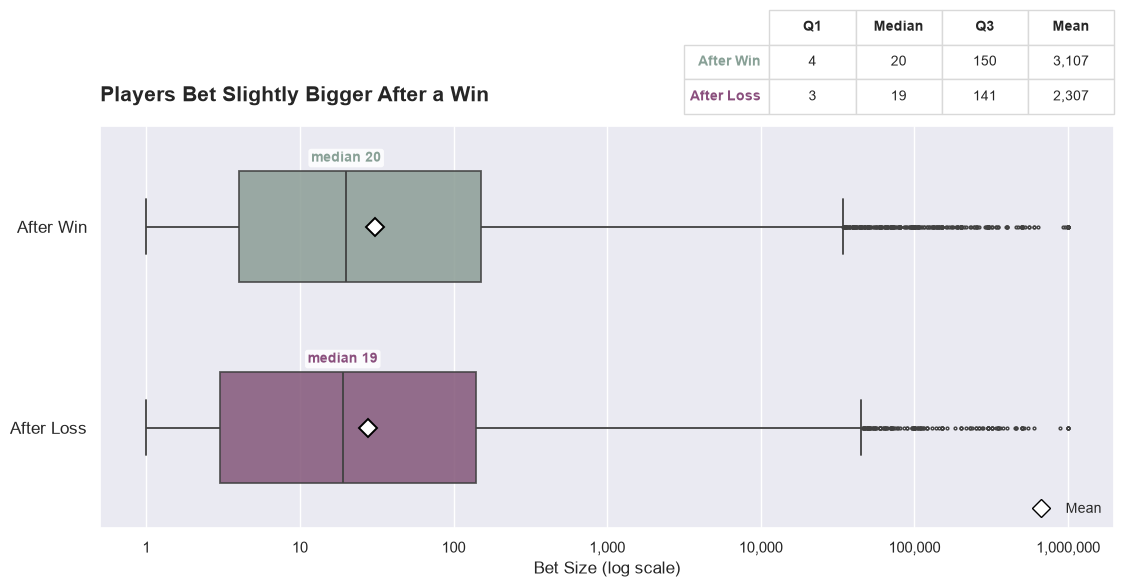

In [2]:
#quartiles + mean of bet size for each previous outcome
summary = seq_df.groupby('PrevOutcome')['Bet'].agg(
    Q1=lambda x: x.quantile(0.25),
    median=lambda x: x.quantile(0.50),
    Q3=lambda x: x.quantile(0.75),
    mean='mean'
)

order = ['After Win', 'After Loss'] #keep win on top, loss on bottom
palette = {'After Win': MUTED_TEAL, 'After Loss': GRAPE_SODA}

fig, ax = plt.subplots(figsize=(12, 6))
fig.subplots_adjust(top=0.78, right=0.97) #leave room up top for the title + stats table

#bet sizes are super skewed so plot them on a log scale, mean shown as a white diamond
sns.boxplot(data=seq_df, x='Bet', y='PrevOutcome', order=order, hue='PrevOutcome', palette=palette, legend=False,
            log_scale=True, width=0.55, fliersize=2, linewidth=1.3, boxprops={'alpha': 0.85},
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 9, 'markeredgewidth': 1.4},
            ax=ax)

#show real bet sizes on the x-axis instead of 10^x
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.set_title('Players Bet Slightly Bigger After a Win', fontsize=15, fontweight='bold', loc='left', pad=18)
ax.set_xlabel('Bet Size (log scale)', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12)

#label the median just above each box so it doesn't overlap the whiskers
for i, outcome in enumerate(order):
    median = summary.loc[outcome, 'median']
    ax.annotate(f"median {median:,.0f}", xy=(median, i - 0.275), xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=palette[outcome],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))

#the rest of the stats go in a little table in the corner so the boxes stay clean
cell_text = [[f"{summary.loc[o, 'Q1']:,.0f}", f"{summary.loc[o, 'median']:,.0f}", f"{summary.loc[o, 'Q3']:,.0f}", f"{summary.loc[o, 'mean']:,.0f}"] for o in order]
table = ax.table(cellText=cell_text, rowLabels=order, colLabels=['Q1', 'Median', 'Q3', 'Mean'],
                 cellLoc='center', rowLoc='right', bbox=[0.66, 1.03, 0.34, 0.26])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('0.85')
    if r == 0: #header row
        cell.set_text_props(fontweight='bold')
    if c == -1 and r > 0: #colour the outcome labels to match their box
        cell.set_text_props(fontweight='bold', color=palette[order[r - 1]])

#little legend so people know the diamond is the mean
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0], [0], marker='D', color='none', markerfacecolor='white', markeredgecolor='black', markersize=9, label='Mean')],
          loc='lower right', frameon=False, fontsize=10)

plt.show()